In [13]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Income group: Average life expectancy of men and women (1960 and 2023)

In [15]:
def resolve_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, path.parent):
        if (candidate / "data" / "processed_data").exists():
            return candidate
    raise FileNotFoundError("Could not find data/processed_data.")

processed_dir = resolve_project_root() / "data" / "processed_data"

# 1) Load datasets
male_df = pd.read_csv(
    processed_dir / "processed_life_expectancy_male.csv"
)
female_df = pd.read_csv(
    processed_dir / "processed_life_expectancy_female.csv"
)

# Clean numeric values
for df in [male_df, female_df]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

# Keep country identifiers to prevent Cartesian product during merge
male_df = male_df[["country_code", "income_group", "year", "value"]].rename(
    columns={"value": "male_life_expectancy"}
)
female_df = female_df[["country_code", "income_group", "year", "value"]].rename(
    columns={"value": "female_life_expectancy"}
)

# Merge on country level
gap_df = male_df.merge(
    female_df, on=["country_code", "income_group", "year"], how="inner"
)

# Drop missing values and compute country-level gender gap
gap_df = gap_df.dropna(subset=["income_group", "male_life_expectancy", "female_life_expectancy"])
gap_df["gender_gap"] = gap_df["female_life_expectancy"] - gap_df["male_life_expectancy"]

# Filter for 1960 and 2023
filtered_df = gap_df[gap_df["year"].isin([1960, 2023])]

# Aggregate average gender gap per income group per year
result = (
    filtered_df.groupby(["income_group", "year"])["gender_gap"]
    .mean()
    .unstack(level="year")
)

# Compute absolute change in gender gap
result["change_in_gap"] = result[2023] - result[1960]

# Find largest change (using abs() in case the question implies magnitude of change)
best_gap = result.reindex(
    result["change_in_gap"].abs().sort_values(ascending=False).index
).head(1)

print(result)
print("\n" + "=" * 50)
print(
    f"Income group with the largest change in gender gap: {best_gap.index[0]} "
    f"({best_gap['change_in_gap'].values[0]:+.2f} years)"
)

year                     1960      2023  change_in_gap
income_group                                          
High income          5.239274  5.184557      -0.054717
Low income           2.839840  4.399200       1.559360
Lower middle income  3.196609  4.739745       1.543136
Upper middle income  4.262407  5.928627       1.666220

Income group with the largest change in gender gap: Upper middle income (+1.67 years)


2. Income group: Variability in life expectancy at birst (1960 and 2023)

In [16]:
def resolve_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, path.parent):
        if (candidate / "data" / "processed_data").exists():
            return candidate
    raise FileNotFoundError("Could not find data/processed_data.")

processed_dir = resolve_project_root() / "data" / "processed_data"

# Load dataset
life_df = pd.read_csv(
    processed_dir / "processed_life_expectancy_total.csv"
)

# Clean numeric columns
life_df["year"] = pd.to_numeric(life_df["year"], errors="coerce").astype("Int64")
life_df["value"] = pd.to_numeric(life_df["value"], errors="coerce")

# Clean income_group column (drop missing or 'Unknown' categories)
life_df = life_df.dropna(subset=["income_group", "value", "year"])
life_df = life_df[life_df["income_group"] != "Unknown"]

# Filter for target years
life_filtered = life_df[life_df["year"].isin([1960, 2023])]

# Compute Standard Deviation (spread) per income group and year
variability = (
    life_filtered.groupby(["income_group", "year"])["value"]
    .std(ddof=1)
    .unstack(level="year")
)

# Calculate change and absolute magnitude of change
variability["change_in_variability"] = variability[2023] - variability[1960]
variability["abs_change"] = variability["change_in_variability"].abs()

# Sort by largest absolute change
sorted_variability = variability.sort_values("abs_change", ascending=False)
best_variability = sorted_variability.head(1)

print("=== Standard Deviation of Life Expectancy by Income Group ===")
print(sorted_variability[[1960, 2023, "change_in_variability"]])

print("\n" + "=" * 60)
print(
    f"Income group with the largest change in variability: {best_variability.index[0]}"
)
print(
    f"1960 Std Dev: {best_variability[1960].values[0]:.2f} years | "
    f"2023 Std Dev: {best_variability[2023].values[0]:.2f} years | "
    f"Change: {best_variability['change_in_variability'].values[0]:+.2f} years"
)

=== Standard Deviation of Life Expectancy by Income Group ===
year                     1960      2023  change_in_variability
income_group                                                  
Upper middle income  7.549349  3.778299              -3.771050
High income          6.909806  4.177049              -2.732757
Low income           6.761530  4.600719              -2.160811
Lower middle income  6.336418  4.896255              -1.440163

Income group with the largest change in variability: Upper middle income
1960 Std Dev: 7.55 years | 2023 Std Dev: 3.78 years | Change: -3.77 years


3. Correlation between fertility rate and life expectancy at birth over the years

In [17]:
def resolve_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, path.parent):
        if (candidate / "data" / "processed_data").exists():
            return candidate
    raise FileNotFoundError("Could not find data/processed_data.")

processed_dir = resolve_project_root() / "data" / "processed_data"

# 1) Load datasets
fertility_df = pd.read_csv(
    processed_dir / "processed_fertility_rate.csv"
)
life_total_df = pd.read_csv(
    processed_dir / "processed_life_expectancy_total.csv"
)

# Clean numeric values
for df in [fertility_df, life_total_df]:
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

fertility_df = fertility_df[["country_name", "country_code", "year", "value"]].rename(
    columns={"value": "fertility_rate"}
)
life_total_df = life_total_df[["country_name", "country_code", "year", "value"]].rename(
    columns={"value": "life_expectancy"}
)

# Merge datasets
merged_df = fertility_df.merge(
    life_total_df,
    on=["country_name", "country_code", "year"],
    how="inner"
).dropna(subset=["fertility_rate", "life_expectancy"])

# Function to compute correlation with a minimum sample size check
def compute_country_corr(group, min_obs=20):
    if len(group) < min_obs:
        return pd.Series({"correlation": None, "obs_count": len(group)})
    corr = group["fertility_rate"].corr(group["life_expectancy"])
    return pd.Series({"correlation": corr, "obs_count": len(group)})

# Aggregate correlation per country
corr_df = (
    merged_df.groupby(["country_name", "country_code"], as_index=False)
    .apply(compute_country_corr, include_groups=False)
    .dropna(subset=["correlation"])
)

# Filter out regional/income aggregates if needed (World Bank regional codes often lack specific country iso3 format or match known regional tags)
# e.g., corr_df = corr_df[~corr_df['country_code'].str.contains('WB|OWID')]

# Sort and slice results
highest_positive = corr_df.sort_values("correlation", ascending=False).head(5)
lowest_negative = corr_df.sort_values("correlation", ascending=True).head(5)
weakest = (
    corr_df.assign(abs_corr=corr_df["correlation"].abs())
    .sort_values("abs_corr", ascending=True)
    .head(5)
)

print("=== Most Negative Correlations (Strongest Inverse Relationship) ===")
print(lowest_negative[["country_name", "correlation", "obs_count"]].to_string(index=False))

print("\n=== Top Positive Correlations (Anomalous / Counter-Demographic) ===")
print(highest_positive[["country_name", "correlation", "obs_count"]].to_string(index=False))

print("\n=== Weakest Correlations (Closest to 0 / No Linear Relationship) ===")
print(weakest[["country_name", "correlation", "obs_count"]].to_string(index=False))

=== Most Negative Correlations (Strongest Inverse Relationship) ===
                                        country_name  correlation  obs_count
                                               India    -0.997265       65.0
                                          South Asia    -0.996793       65.0
                             South Asia (IDA & IBRD)    -0.996793       65.0
Latin America & the Caribbean (IDA & IBRD countries)    -0.995294       65.0
                           Latin America & Caribbean    -0.994758       65.0

=== Top Positive Correlations (Anomalous / Counter-Demographic) ===
            country_name  correlation  obs_count
                Zimbabwe     0.310384       65.0
                 Lesotho     0.279904       65.0
      Russian Federation     0.153765       65.0
                    Chad     0.076498       65.0
Central African Republic     0.073213       65.0

=== Weakest Correlations (Closest to 0 / No Linear Relationship) ===
            country_name  correlation

  country_name  correlation
0     Eswatini    -0.003891
1        India    -0.997265
2      Lesotho     0.279904
3     Zimbabwe     0.310384


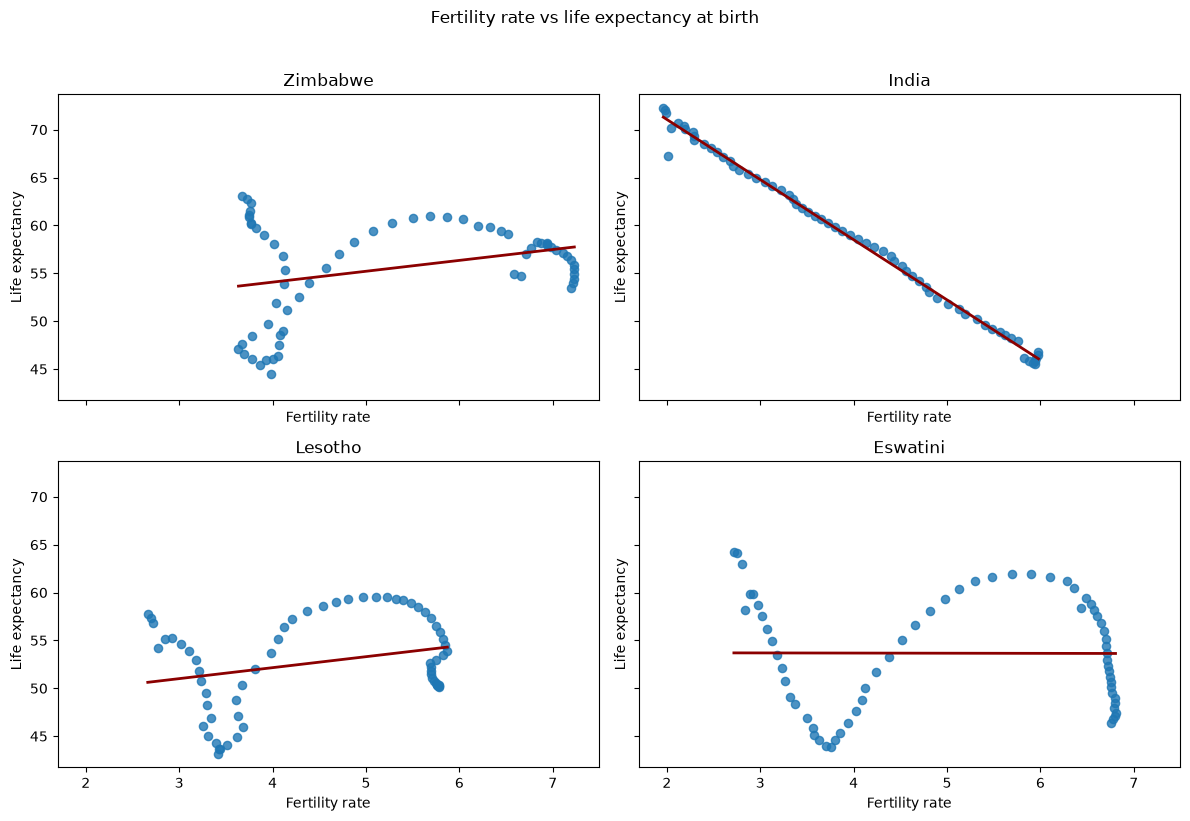

In [18]:
def load_fertility_life_frames():
    processed_dir = resolve_project_root() / "data" / "processed_data"
    fertility_df = pd.read_csv(processed_dir / "processed_fertility_rate.csv")
    life_total_df = pd.read_csv(processed_dir / "processed_life_expectancy_total.csv")
    for df in (fertility_df, life_total_df):
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
    fertility_df = fertility_df[["country_name", "country_code", "year", "value"]].rename(
        columns={"value": "fertility_rate"}
    )
    life_total_df = life_total_df[["country_name", "country_code", "year", "value"]].rename(
        columns={"value": "life_expectancy"}
    )
    return fertility_df, life_total_df

fertility_df, life_total_df = load_fertility_life_frames()

selected_countries = ["Zimbabwe", "India", "Lesotho", "Eswatini"]

plot_df = fertility_df.merge(
    life_total_df,
    on=["country_name", "country_code", "year"],
    how="inner",
)
plot_df = plot_df[plot_df["country_name"].isin(selected_countries)].copy()

# Correlations (with clean data)
corr_rows = []
for country_name, group in plot_df.groupby("country_name"):
    clean = group.dropna(subset=["fertility_rate", "life_expectancy"])
    if len(clean) > 1:
        corr = clean["fertility_rate"].corr(clean["life_expectancy"])
    else:
        corr = np.nan
    corr_rows.append({"country_name": country_name, "correlation": corr})

country_corr_plot = pd.DataFrame(corr_rows)
print(country_corr_plot)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, country_name in zip(axes, selected_countries):
    country_data = plot_df[plot_df["country_name"] == country_name].dropna(
        subset=["fertility_rate", "life_expectancy"]
    )

    if len(country_data) < 2:
        ax.set_title(f"{country_name} (not enough data)")
        ax.set_xlabel("Fertility rate")
        ax.set_ylabel("Life expectancy")
        continue

    x = country_data["fertility_rate"].to_numpy(dtype=float)
    y = country_data["life_expectancy"].to_numpy(dtype=float)

    # Need variation in x for a stable line fit
    if np.nanstd(x) == 0 or not np.isfinite(x).all() or not np.isfinite(y).all():
        ax.scatter(x, y, s=35, alpha=0.8)
        ax.set_title(f"{country_name} (constant fertility)")
        ax.set_xlabel("Fertility rate")
        ax.set_ylabel("Life expectancy")
        continue

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    fitted = slope * x_line + intercept

    ax.scatter(x, y, s=35, alpha=0.8)
    ax.plot(x_line, fitted, color="darkred", linewidth=2)
    ax.set_title(country_name)
    ax.set_xlabel("Fertility rate")
    ax.set_ylabel("Life expectancy")

fig.suptitle("Fertility rate vs life expectancy at birth", y=1.02)
plt.tight_layout()
plt.show()